In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

In [4]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('stage1.csv')

# Feature Selection

In [5]:
df.columns

Index(['Unnamed: 0', 'ID', 'Year_Birth', 'Education', 'Marital_Status',
       'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntCoke',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'tanggal_dummy', 'Usia', 'Is_Couple', 'Is_SMA', 'Anak', 'cmp_masuk',
       'Spent', 'deals_rate', 'conversion_rate', 'rentang'],
      dtype='object')

In [6]:
df.drop(columns=['Unnamed: 0','ID','Z_CostContact','Z_Revenue','Year_Birth','Education','Marital_Status','Kidhome', 'Teenhome','Dt_Customer','MntCoke','MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2','Response','tanggal_dummy','Usia'], inplace=True)

In [7]:
df['Complain'].max()

1

# Feature Encoding

In [8]:
Urutan = {'Muda': 1, 'Tua': 2, 'Lansia': 3}
df['rentang'] = df['rentang'].map(Urutan)
df.head()

,Income,Recency,Complain,Is_Couple,Is_SMA,Anak,cmp_masuk,Spent,deals_rate,conversion_rate,rentang
0,58138000.0,58,0,0,0,0,0,1617000,0.120000,0.533333,3
1,46344000.0,38,0,0,0,2,0,27000,0.333333,0.166667,3
2,71613000.0,26,0,1,0,0,0,776000,0.047619,0.666667,2
3,26646000.0,26,0,1,0,1,0,53000,0.250000,0.250000,1
4,58293000.0,94,0,1,0,1,0,422000,0.263158,0.500000,2


# Standarisasi Feature

In [9]:
from sklearn.preprocessing import StandardScaler
kolom_standar = ['Income', 'Recency', 'Spent','Anak','cmp_masuk','rentang']
scaler = StandardScaler()

df[kolom_standar] = scaler.fit_transform(df[kolom_standar])

# Clustering

In [10]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(df)
    
    distortions.append(sum(np.min(cdist(df, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / df.shape[0])
    
    inertias.append(kmeanModel.inertia_)
    
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

Distortion values:
1 : 6.319849522218966
2 : 4.510581546910262
3 : 3.9163481301317042
4 : 3.4643019725487147
5 : 3.199007872604983
6 : 2.983886802694788
7 : 2.717826661150082
8 : 2.520988677751162
9 : 2.3687063585102446


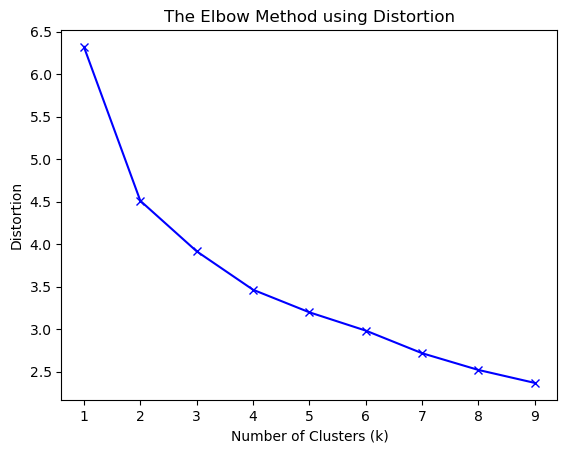

In [11]:
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

Inertia values:
1 : 13935.268196492822
2 : 9945.832310937127
3 : 8635.547626940426
4 : 7638.785849469927
5 : 7053.812359093972
6 : 6579.470399942002
7 : 5992.807787835919
8 : 5558.780034441315
9 : 5222.997520515082


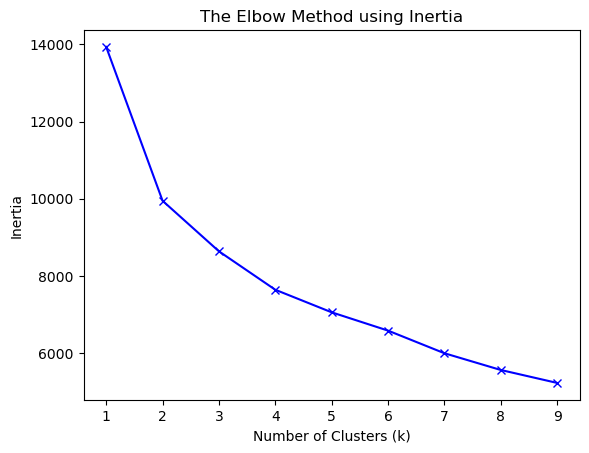

In [12]:
print("Inertia values:")
for key, val in mapping2.items():
    print(f'{key} : {val}')

plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

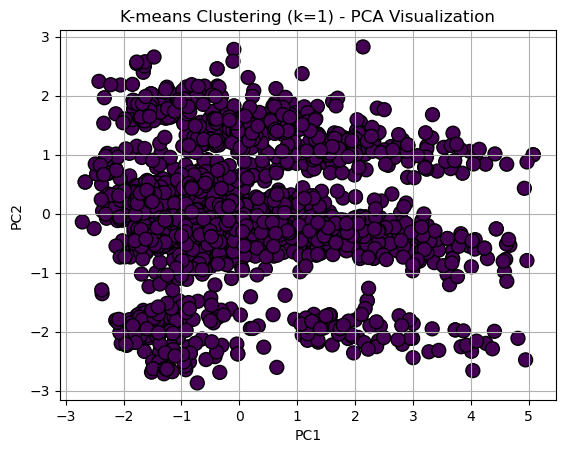

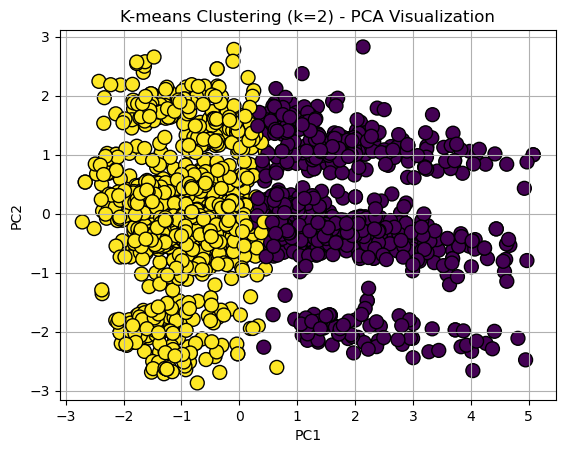

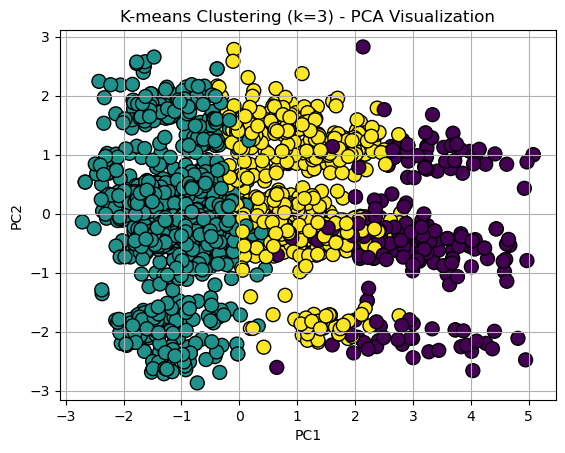

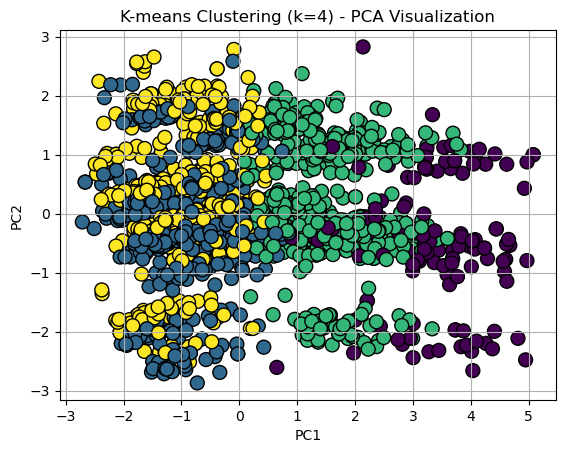

In [13]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)  

k_range = range(1, 5)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(df)

    # Visualisasi pake hasil PCA
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', marker='o', edgecolor='k', s=100)
    plt.title(f'K-means Clustering (k={k}) - PCA Visualization')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid()
    plt.show()

For n_clusters = 2 The average silhouette_score is : 0.27779513536875744
For n_clusters = 3 The average silhouette_score is : 0.17123651413393035
For n_clusters = 4 The average silhouette_score is : 0.20451923469002345
For n_clusters = 5 The average silhouette_score is : 0.18277340000674666
For n_clusters = 6 The average silhouette_score is : 0.18132290648007476


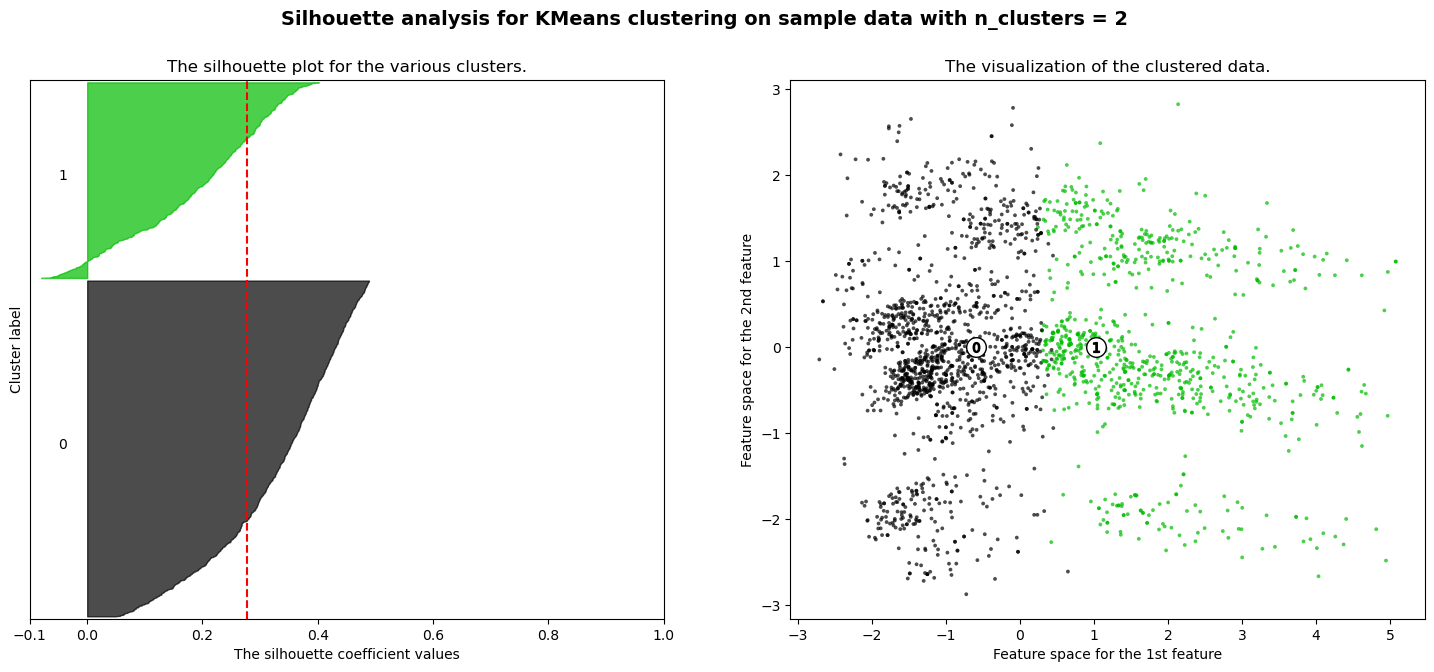

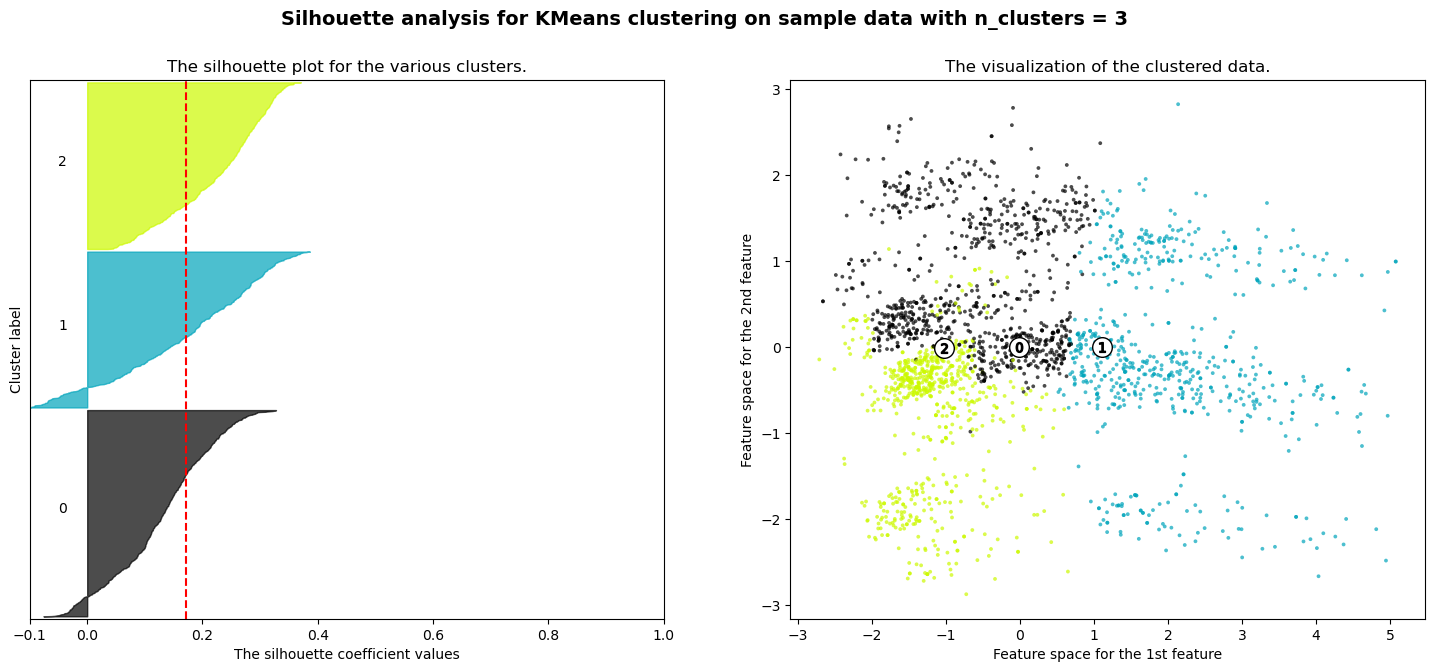

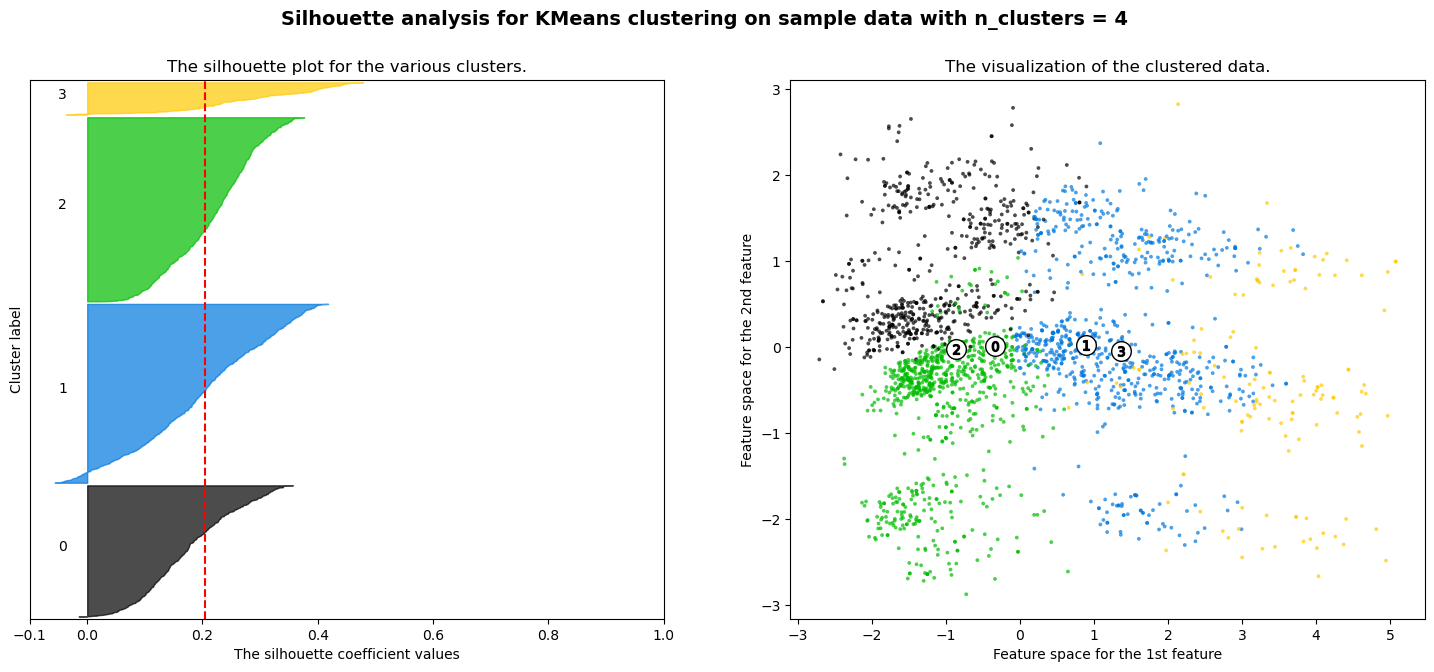

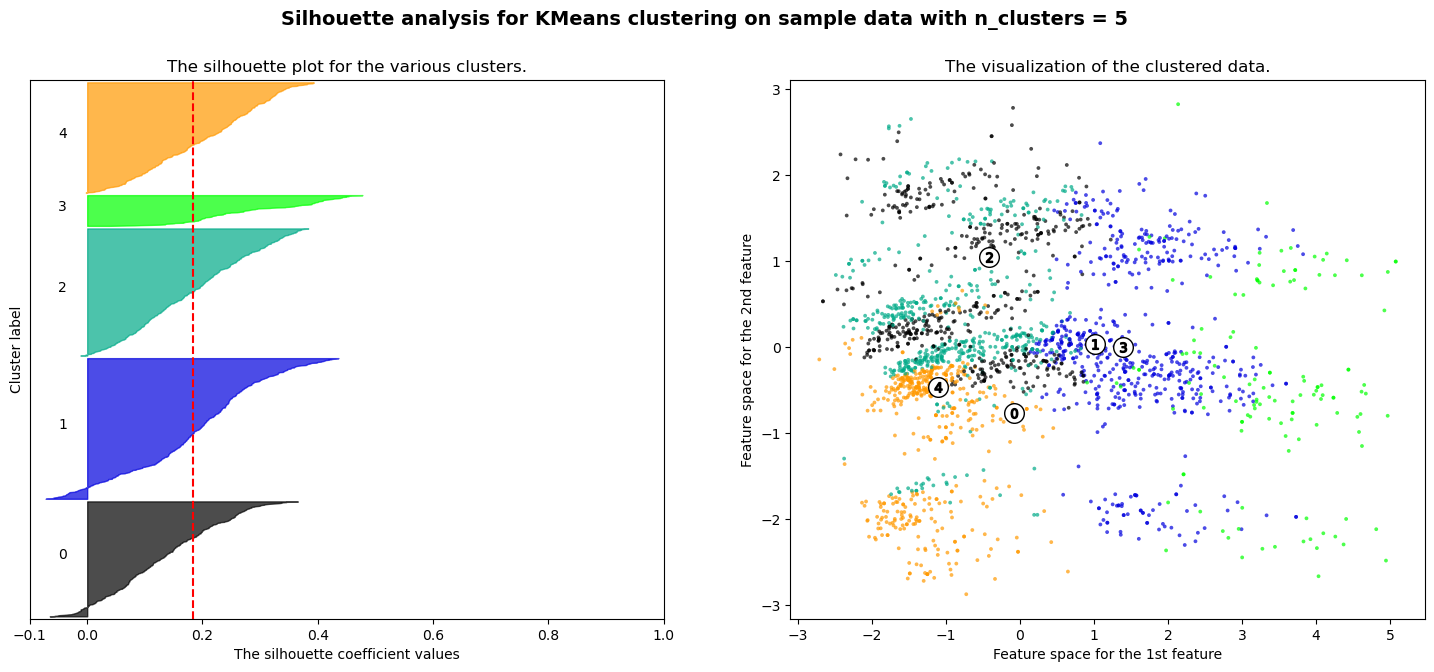

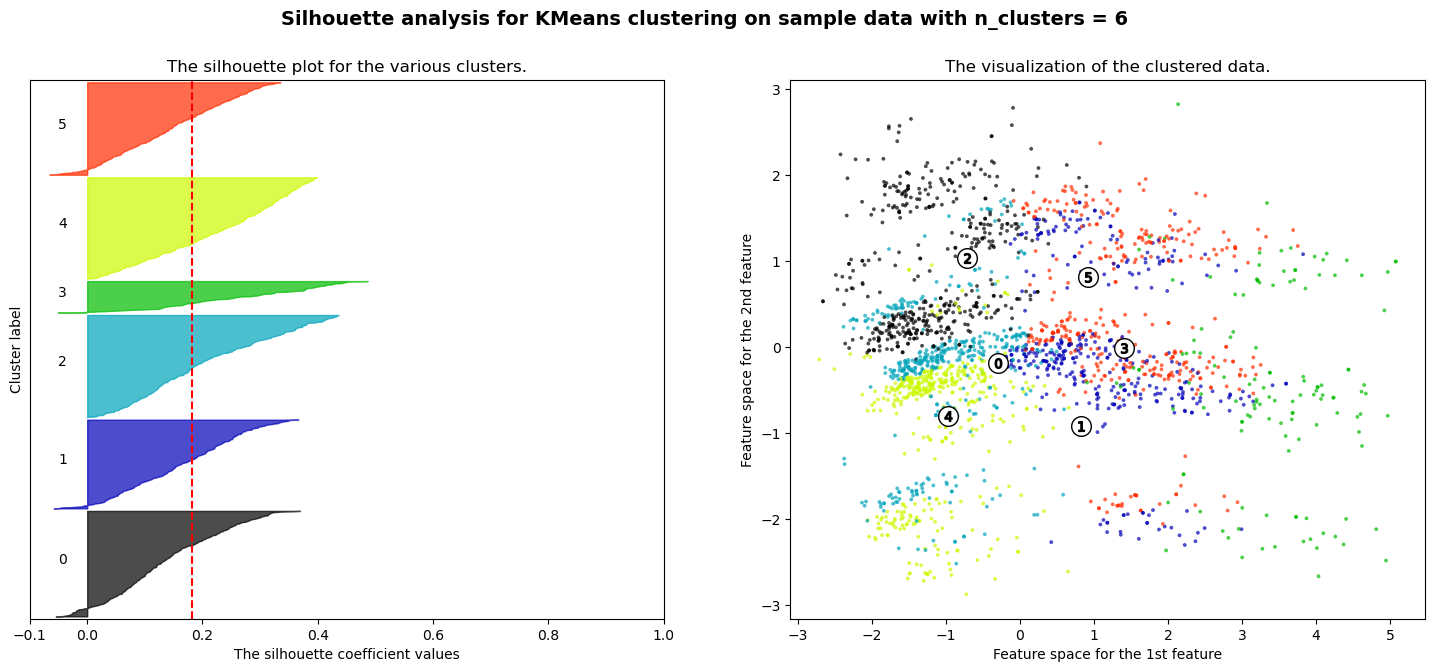

In [14]:
#Silhoute Score

from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(df) + (n_clusters + 1) * 10])


    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(df)

    silhouette_avg = silhouette_score(df, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    sample_silhouette_values = silhouette_samples(df, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):

        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X_pca[:, 0], X_pca[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

# EDA Cluster

In [15]:
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(df)
df.head()

,Income,Recency,Complain,Is_Couple,Is_SMA,Anak,cmp_masuk,Spent,deals_rate,conversion_rate,rentang,Cluster
0,0.314651,0.310830,0,0,0,-1.266589,-0.439991,1.679323,0.120000,0.533333,1.533399,0
1,-0.254877,-0.380600,0,0,0,1.403420,-0.439991,-0.963897,0.333333,0.166667,1.533399,1
2,0.965354,-0.795458,0,1,0,-1.266589,-0.439991,0.281242,0.047619,0.666667,-0.196972,0
3,-1.206087,-0.795458,0,1,0,0.068415,-0.439991,-0.920675,0.250000,0.250000,-1.927342,1
4,0.322136,1.555404,0,1,0,0.068415,-0.439991,-0.307248,0.263158,0.500000,-0.196972,1


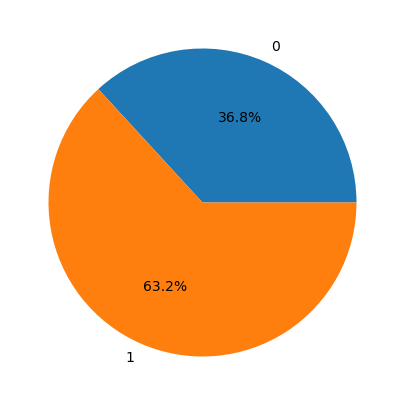

In [16]:
pivot = df.groupby('Cluster').agg({'Cluster':'count'}).rename(columns={'Cluster':'Total'}).reset_index()
plt.figure(figsize=(7,5))
plt.pie(pivot['Total'],labels=pivot['Cluster'],autopct='%1.1f%%')
plt.show()

In [17]:
pivot

,Cluster,Total
0,0,812
1,1,1393


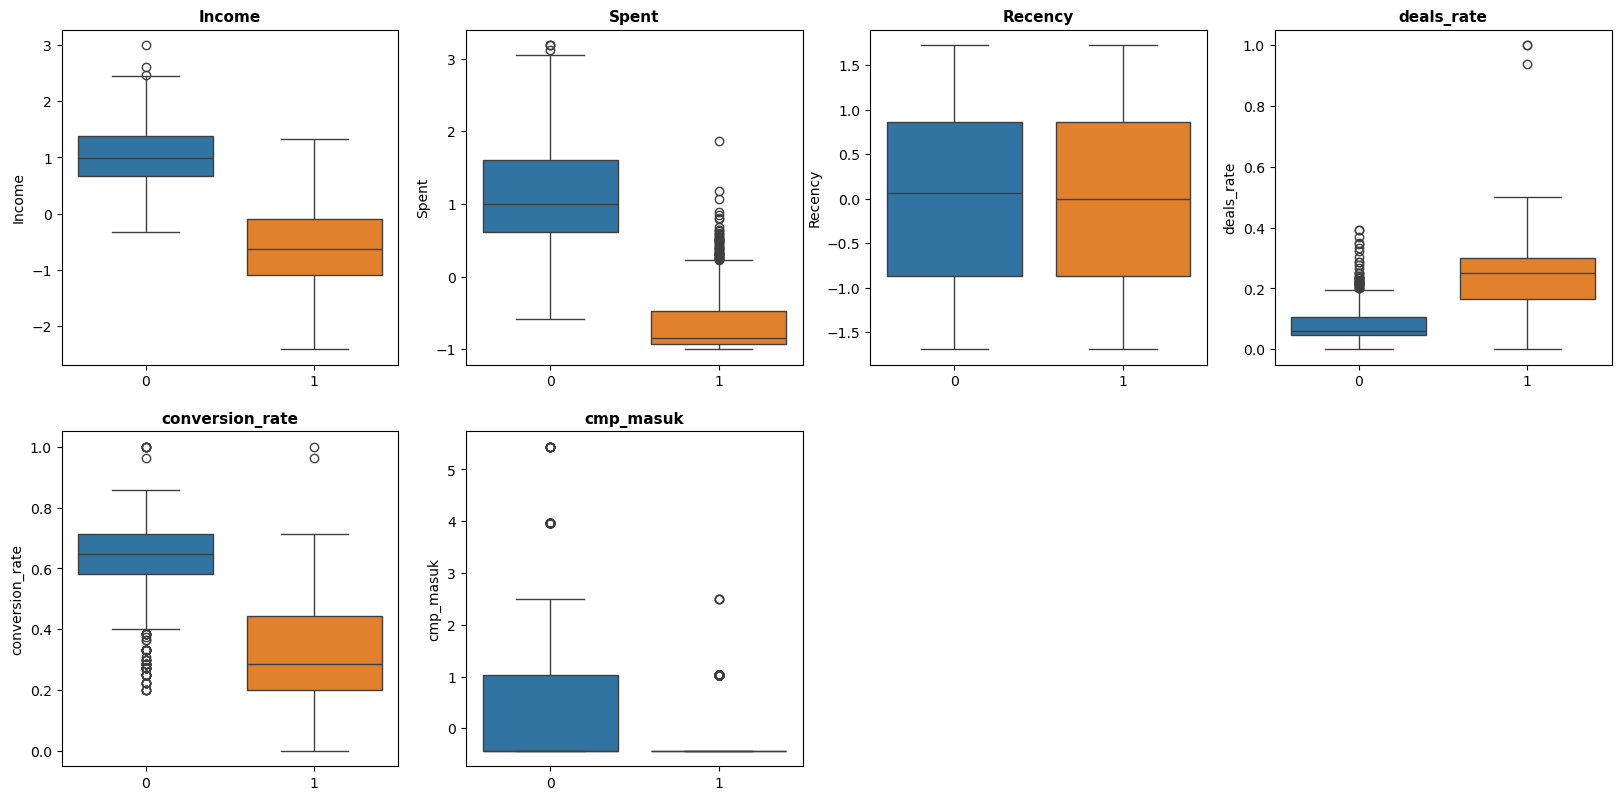

In [ ]:
numerics = ['Income', 'Spent', 'Recency', 'deals_rate', 'conversion_rate', 'cmp_masuk']
plt.figure(figsize=(20,20))
for i, col in enumerate(numerics):
    ax = plt.subplot(4, 4, i + 1)
    sns.boxplot(data=df, x='Cluster', y=col, hue='Cluster',legend=False, ax=ax)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

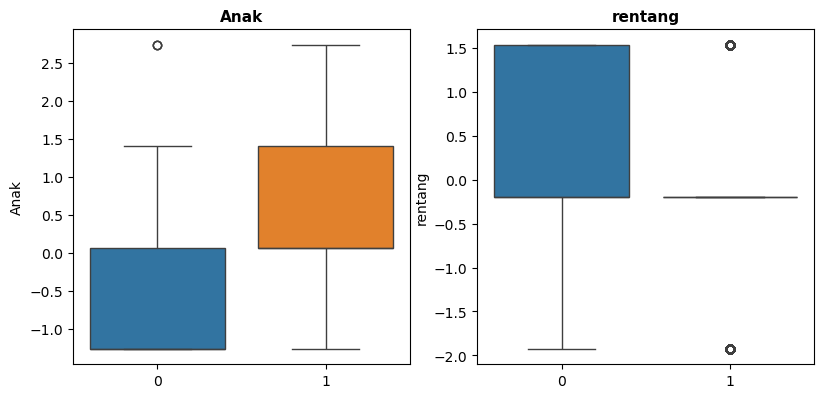

In [26]:
numerics = ['Anak','rentang']
plt.figure(figsize=(20,20))
for i, col in enumerate(numerics):
    ax = plt.subplot(4, 4, i + 1)
    sns.boxplot(data=df, x='Cluster', y=col, hue='Cluster',legend=False, ax=ax)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')